# Buildup of a Sea Ice Fraction Plot

## Origin of Files

In [1]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4

#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc
#
#
#Extracting DIFFERENT data:
#
#        Creating Means:
#        cdo ymonmean PI.kepler_atm2d_merged_remapped_1770_1800.nc ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc
#



## Basic Import Statements

In [2]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm
import os
import socket
import psutil
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Loading rcParams

In [3]:
import importlib
import plot_settings
importlib.reload(plot_settings)
plot_settings.load_rcParams()

## Loading Data (ymonmeans)

In [4]:
def determine_system() -> str:
    many_cores  = os.cpu_count() > 16
    lots_of_ram = psutil.virtual_memory().total > 64 * 1024**3  # more than 64 GB
    if many_cores and lots_of_ram:
        return 'Cluster'
    else:
        return 'Jakob_Laptop'

if determine_system() == 'Jakob_Laptop':
    location_of_data = '../'
else:
    location_of_data = '/data/modeldata/ICON/icon-paleo/'

print('Loading ymonmean Data')
PI      = xr.open_dataset(location_of_data + 'PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG     = xr.open_dataset(location_of_data + 'LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG_ghg = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')



#PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG  = xr.open_dataset('../LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')


Loading ymonmean Data


## Deriving Worldmap Anomalies

In [5]:
#extract Juli
def extract_month(PI: xr.DataArray, month: int = 7) -> xr.DataArray:
    PI_mon = PI.sel(time=PI.time.dt.month == month)
    return PI_mon

def remove_useless_dims(ds):
    if 'height_2' in PI.dims:
        ds = ds.squeeze('height_2')
    if 'height' in PI.dims:
        ds = ds.squeeze('height')
    return ds

def get_annual_mean(ds):
    #takes annual mean only for ymonmean data!
    return ds.mean(dim='time')

PI,LIG,LIG_ghg = [remove_useless_dims(ds) for ds in [PI,LIG,LIG_ghg]]


PI_Jul      = extract_month(PI,      month =7)
LIG_Jul     = extract_month(LIG,     month =7)
LIG_ghg_Jul = extract_month(LIG_ghg, month =7)

PI_Jan      = extract_month(PI,      month =1)
LIG_Jan     = extract_month(LIG,     month =1)
LIG_ghg_Jan = extract_month(LIG_ghg, month =1)

PI_ann,LIG_ann,LIG_ghg_ann = [get_annual_mean(ds) for ds in [PI,LIG,LIG_ghg]] #ann stands for annual not Anomaly




# derive anomaly
Anom_Jul_LIG_PI = LIG_Jul - PI_Jul
Anom_Jan_LIG_PI = LIG_Jan - PI_Jan
Anom_ann_LIG_PI = LIG_ann - PI_ann



In [27]:
Anom_Jul_LIG_PI

<xarray.Dataset>
Dimensions:        (time: 1, lon: 240, lat: 120, bnds: 2)
Coordinates:
  * time           (time) datetime64[ns] 1800-07-01
  * lon            (lon) float64 -180.0 -178.5 -177.0 ... 175.5 177.0 178.5
  * lat            (lat) float64 -90.0 -88.5 -87.0 -85.5 ... 84.0 85.5 87.0 88.5
    height         float64 10.0
    height_2       float64 2.0
Dimensions without coordinates: bnds
Data variables: (12/39)
    time_bnds      (time, bnds) timedelta64[ns] 00:00:00 00:00:00
    pres_msl       (time, lat, lon) float32 90.14 90.14 90.14 ... -44.42 -44.73
    pres_sfc       (time, lat, lon) float32 29.79 29.79 29.79 ... -43.9 -44.22
    t_s            (time, lat, lon) float32 -0.2301 -0.2301 ... 1.503 1.505
    clct           (time, lat, lon) float32 1.656 1.656 1.656 ... 3.19 3.198
    tot_prec_rate  (time, lat, lon) float32 9.048e-08 9.048e-08 ... -1.081e-06
    ...             ...
    t_ice          (time, lat, lon) float32 -0.2301 -0.2301 ... 1.565 1.567
    h_ice          (time, lat, lon) float32 0.0 0.0 0.0 ... -0.3122 -0.3132
    albvisdif      (time, lat, lon) float32 0.0 0.0 0.0 ... -7.369 -7.371 -7.374
    albvisdir      (time, lat, lon) float32 0.0 0.0 0.0 ... -6.893 -6.896 -6.899
    albnirdif      (time, lat, lon) float32 0.0 0.0 0.0 ... -7.369 -7.371 -7.374
    albnirdir      (time, lat, lon) float32 0.0 0.0 0.0 ... -6.893 -6.896 -6.899

In [6]:
LIG_Jul["fr_seaice"]

<xarray.DataArray 'fr_seaice' (time: 1, lat: 120, lon: 240)>
[28800 values with dtype=float32]
Coordinates:
  * time      (time) datetime64[ns] 1800-07-01
  * lon       (lon) float64 -180.0 -178.5 -177.0 -175.5 ... 175.5 177.0 178.5
  * lat       (lat) float64 -90.0 -88.5 -87.0 -85.5 ... 84.0 85.5 87.0 88.5
    height    float64 10.0
    height_2  float64 2.0
Attributes:
    standard_name:  fr_seaice
    long_name:      fraction of sea ice
    units:          1
    param:          0.2.10

## Basic SIF Plot LIG

Text(0.5, 1.0, 'Sea Ice Fraction - LIG July')

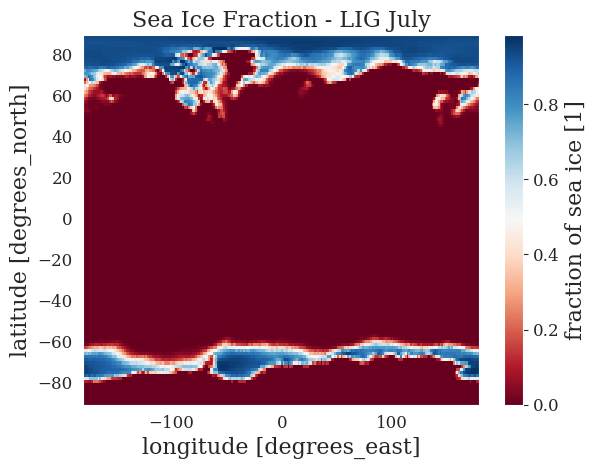

In [7]:
LIG_Jul["fr_seaice"].plot(cmap = 'RdBu')
plt.title("Sea Ice Fraction - LIG July")

## Basic SIF Plot PI

Text(0.5, 1.0, 'Sea Ice Fraction - PI July')

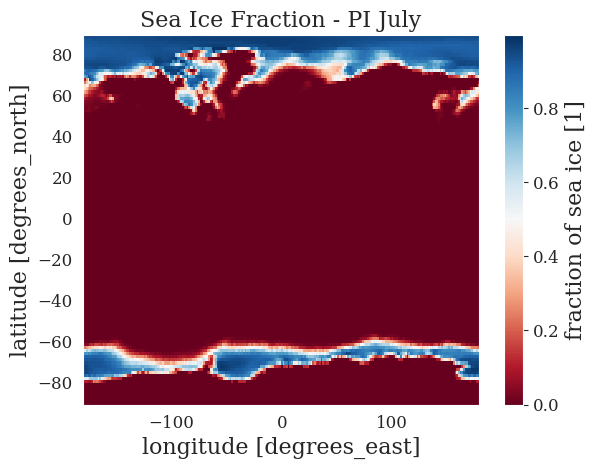

In [8]:
PI_Jul["fr_seaice"].plot(cmap = 'RdBu')
plt.title("Sea Ice Fraction - PI July")

## Plotting SIF Anomaly

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

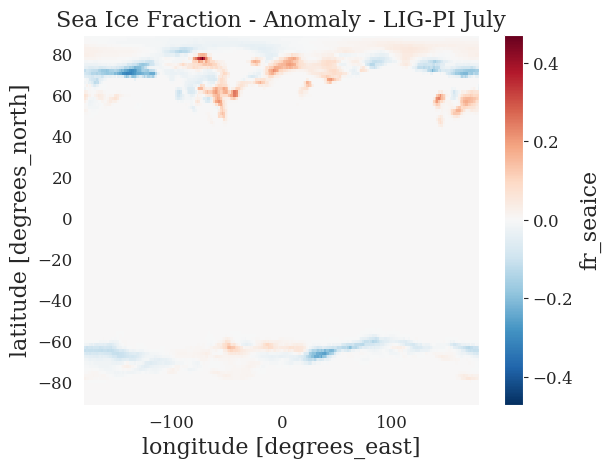

In [9]:
Anom_Jul_LIG_PI["fr_seaice"].plot()
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Adding Coastlines

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

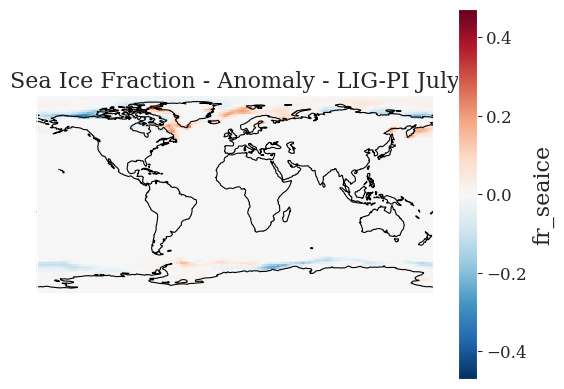

In [10]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Inverting Colormap

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

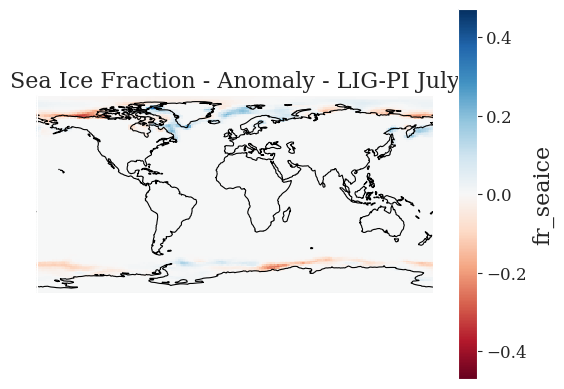

In [11]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Switching to North Pole South Pole Scale

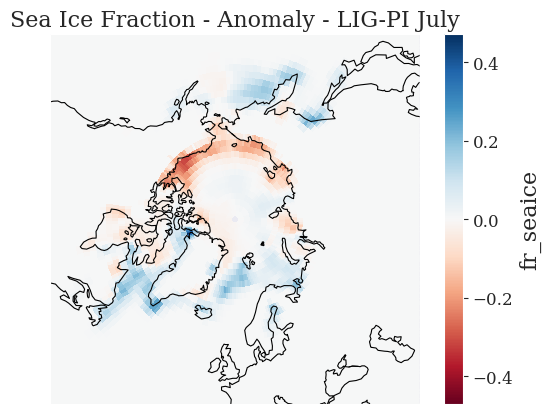

In [12]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

## Full Plot in one Image

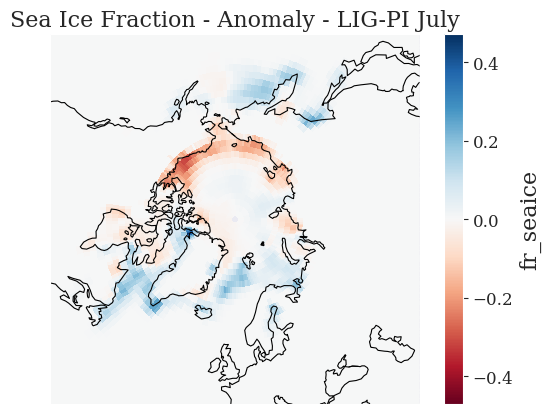

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

## Big Sea Ice Anomaly Plot

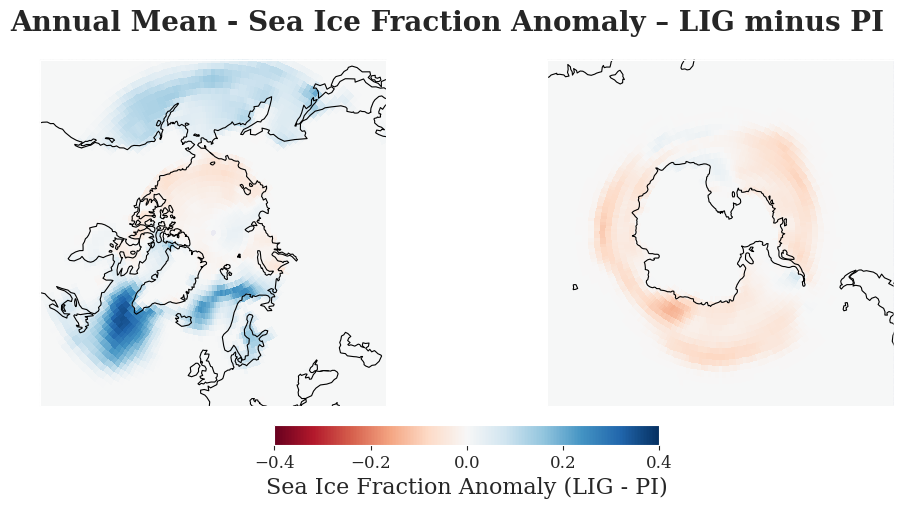

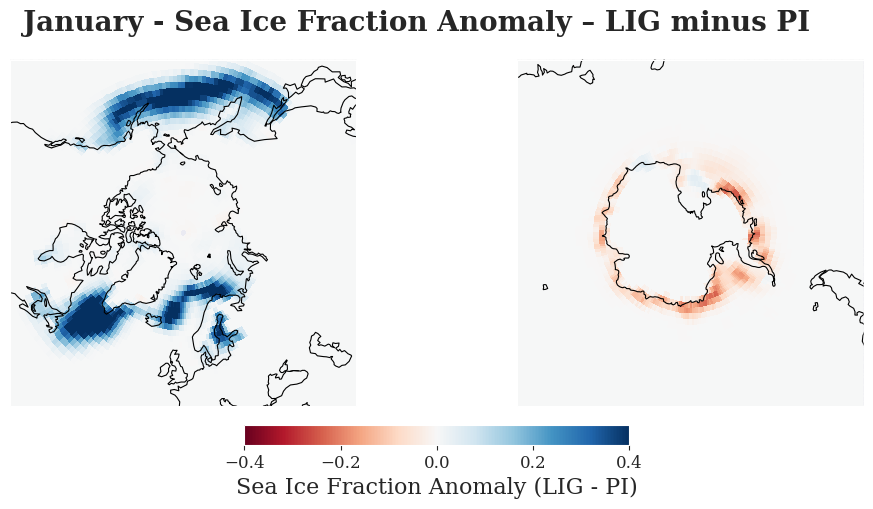

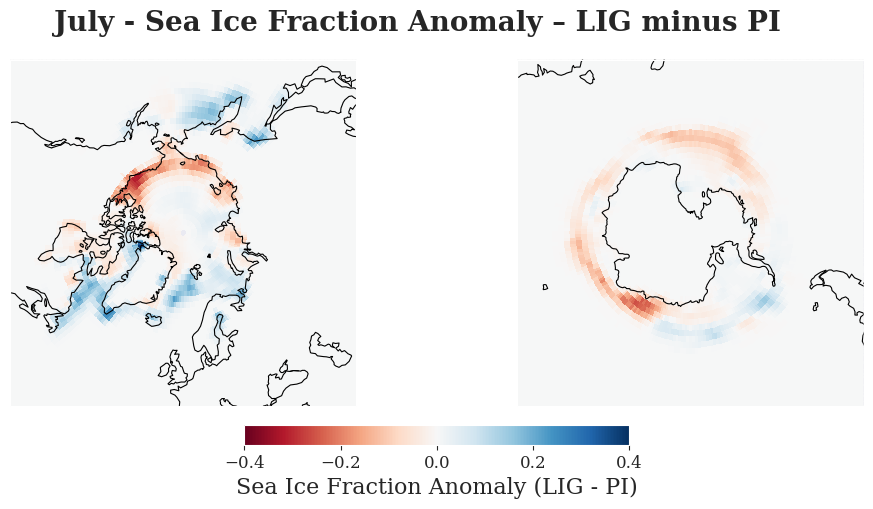

In [22]:
datasets = [
    (Anom_ann_LIG_PI, "Annual Mean"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_Jul_LIG_PI, "July"),
]

for ds, label in datasets:
    data = ds["fr_seaice"]

    # Compute symmetric colorbar limits per plot
    #vmax = np.nanpercentile(np.abs(data.values), 98)
    vmax = 0.4
    vmin = -vmax

    fig = plt.figure(figsize=(12, 5))

    # Northern Hemisphere
    ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
    im = data.plot(ax=ax_n, transform=ccrs.PlateCarree(), cmap="RdBu",
                   vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    #ax_n.set_title("Northern Hemisphere")
    ax_n.set_title("")

    # Southern Hemisphere
    ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo(central_longitude=180))
    data.plot(ax=ax_s, transform=ccrs.PlateCarree(), cmap="RdBu",
              vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    #ax_s.set_title("Southern Hemisphere")
    ax_s.set_title("")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Sea Ice Fraction Anomaly (LIG - PI)")

    fig.suptitle(f"{label} - Sea Ice Fraction Anomaly – LIG minus PI ",
                 fontsize=20, fontweight="bold")
    plt.savefig(f'figs/sif_{label}_anom_lig_pi.png')
    

## Same Sea Ice Anomaly Plot but different Colorbarlimits

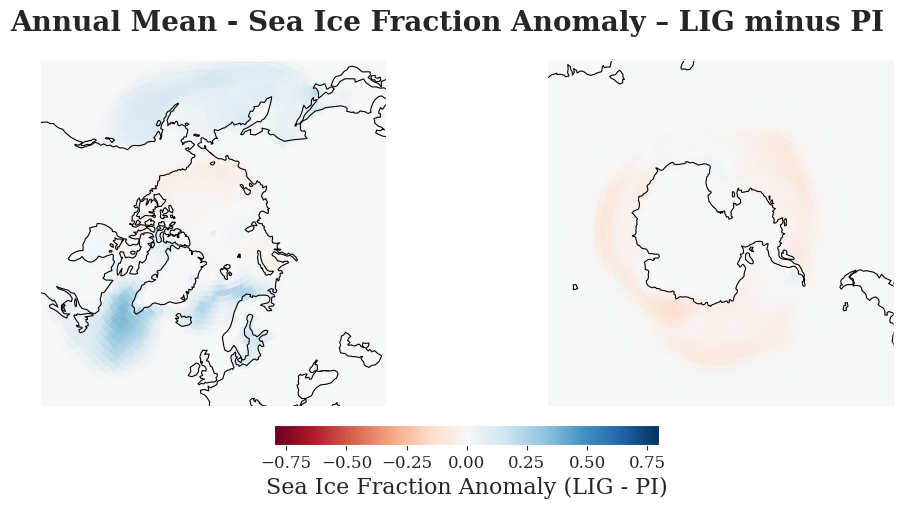

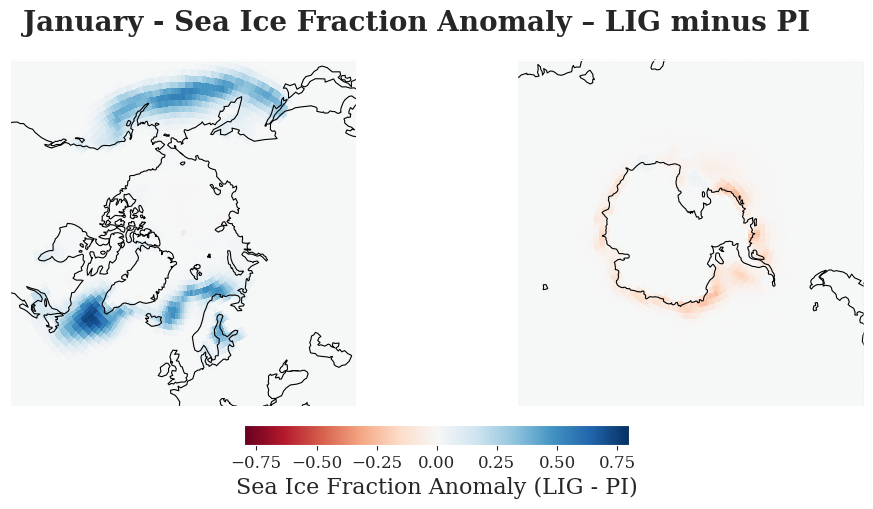

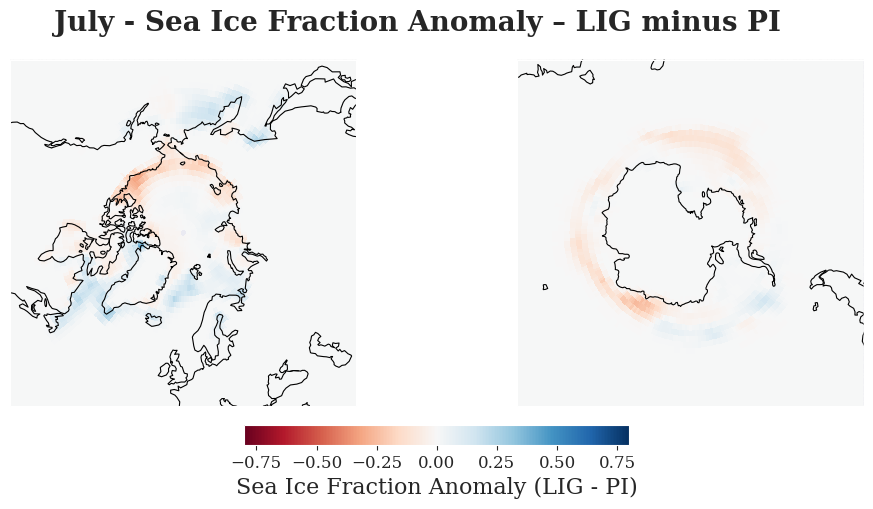

In [26]:
datasets = [
    (Anom_ann_LIG_PI, "Annual Mean"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_Jul_LIG_PI, "July"),
]

for ds, label in datasets:
    data = ds["fr_seaice"]

    # Compute symmetric colorbar limits per plot
    #vmax = np.nanpercentile(np.abs(data.values), 98)
    vmax = 0.8
    vmin = -vmax

    fig = plt.figure(figsize=(12, 5))

    # Northern Hemisphere
    ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
    im = data.plot(ax=ax_n, transform=ccrs.PlateCarree(), cmap="RdBu",
                   vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    #ax_n.set_title("Northern Hemisphere")
    ax_n.set_title("")

    # Southern Hemisphere
    ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo(central_longitude=180))
    data.plot(ax=ax_s, transform=ccrs.PlateCarree(), cmap="RdBu",
              vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    #ax_s.set_title("Southern Hemisphere")
    ax_s.set_title("")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Sea Ice Fraction Anomaly (LIG - PI)")

    fig.suptitle(f"{label} - Sea Ice Fraction Anomaly – LIG minus PI ",
                 fontsize=20, fontweight="bold")
    plt.savefig(f'figs/sif_{label}_anom_lig_pi_0_8_colorbar_limits.png')

# Proof Kiras Plot is "Wrong"

Text(0.5, 1.0, 'Sea Ice Fraction - PI - July')

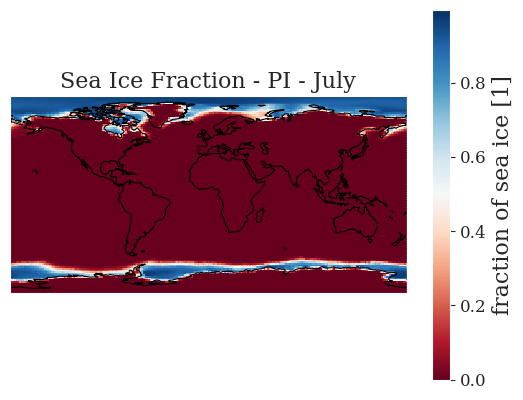

In [15]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
PI_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - PI - July")

Text(0.5, 1.0, 'Sea Ice Fraction - LIG - July')

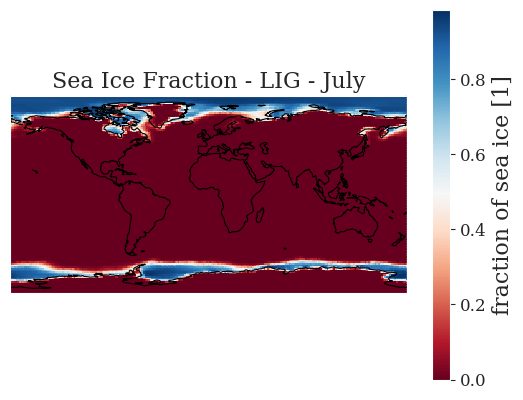

In [16]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
LIG_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - LIG - July")

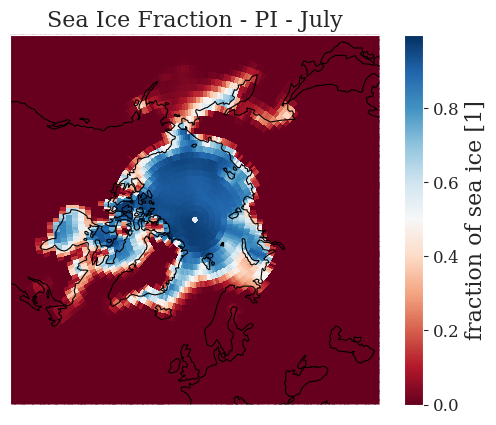

In [17]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
PI_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - PI - July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

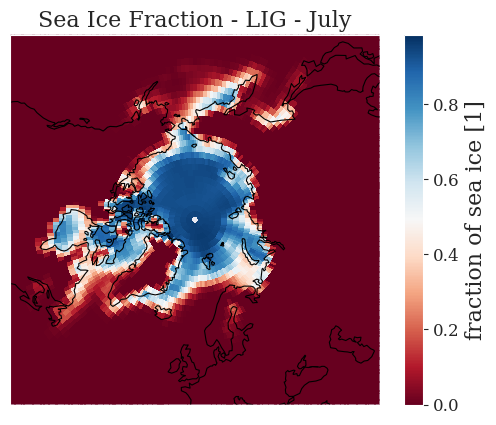

In [18]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
LIG_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - LIG - July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

### In the above plot at the area south of greenland the LIG sea ice is 0.5 at Maximum (probably reather 0.3-0.4). So the Anomaly LIG-PI cannot be higher! But in Kiras Plot there we have an anomaly of 0.8
I think Kiras Data Plots use  some different data! Also the position of the maxima and minima is sometimes quite different.